
# Notebook 01 - Tạo dataset từ AzurePackingTraceV1 (.sqlite)

Notebook này dành cho người mới hoàn toàn.  
Mục tiêu của notebook là biến file `.sqlite` của Azure Packing Trace thành một file:

- `workload_real.csv`

Đây sẽ là file đầu vào để train mô hình PPO ở notebook tiếp theo.

## Ý tưởng rất ngắn gọn

Dữ liệu của bạn có 2 bảng:

- **vm**: cho biết VM nào bắt đầu lúc nào, kết thúc lúc nào
- **vmType**: cho biết mỗi loại VM dùng bao nhiêu core

Ta sẽ làm như sau:

1. Gộp bảng `vmType` theo `vmTypeId`
2. Dùng `core` làm đại diện cho nhu cầu tài nguyên
3. Tại mỗi timestep, cộng tổng `core` của tất cả VM đang còn sống
4. Chuẩn hóa chuỗi đó thành cột `demand`
5. Lưu ra CSV

## Vì sao làm cách này?
Vì project RL hiện tại của bạn chỉ cần một chuỗi workload theo thời gian.  
Chuỗi đó chính là `demand`.


In [7]:

# Nếu bạn chạy notebook lần đầu mà báo thiếu thư viện, bỏ comment dòng dưới rồi chạy 1 lần:
# !pip install pandas numpy matplotlib


In [8]:

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.azure_workload_utils import extract_workload_from_azure_packing

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = D:\HK6\HOC MAY TANG CUONG CHO CAC HE THONG MANG\DA\azure_drl_beginner_project\azure_drl_beginner_project



## Bước 1 - Khai báo đường dẫn file SQLite

Bạn chỉ cần sửa `DB_PATH` cho đúng máy của bạn.

Ví dụ:
- Windows: `r"D:\HK6\...\packing_trace_zone_a_v1.sqlite"`
- Hoặc nếu bạn chép file vào thư mục `data`, có thể dùng đường dẫn tương đối.


In [ ]:

DB_PATH = r"D:\HK6\Hoc may tang cuong cho cac he thong mang\DA\AzurePackingTraceV1\packing_trace_zone_a_v1.sqlite"
OUTPUT_CSV = PROJECT_ROOT / "data" / "workload_real.csv"

print("DB_PATH =", DB_PATH)
print("OUTPUT_CSV =", OUTPUT_CSV)


DB_PATH = D:\HK6\Hoc may tang cuong cho cac he thong mang\DA\AzurePackingTraceV1\packing_trace_zone_a_v1.sqlite
OUTPUT_CSV = D:\HK6\HOC MAY TANG CUONG CHO CAC HE THONG MANG\DA\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real.csv



## Bước 2 - Kiểm tra file có tồn tại không
Nếu cell này in ra `True` là ổn.


In [10]:

Path(DB_PATH).exists()


True


## Bước 3 - Xem nhanh trong database có những bảng nào

Bước này để bạn hiểu dữ liệu trước khi trích workload.


In [11]:

conn = sqlite3.connect(DB_PATH)

tables_df = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)
tables_df


,name
0,vm
1,vmType



## Bước 4 - Xem schema và số dòng của 2 bảng chính
Ở file bạn upload, thường sẽ có:

- `vm`
- `vmType`


In [12]:

for table_name in ["vm", "vmType"]:
    print("\n" + "=" * 70)
    print("TABLE:", table_name)
    schema = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
    print(schema)
    count_df = pd.read_sql_query(f"SELECT COUNT(*) AS row_count FROM {table_name};", conn)
    print("Số dòng =", int(count_df.loc[0, "row_count"]))



TABLE: vm
   cid       name     type  notnull dflt_value  pk
0    0       vmId  INTEGER        1       None   1
1    1   tenantId  INTEGER        0       None   0
2    2   vmTypeId  INTEGER        0       None   0
3    3   priority  INTEGER        0       None   0
4    4  starttime     REAL        0       None   0
5    5    endtime     REAL        0       None   0
Số dòng = 5559800

TABLE: vmType
   cid       name     type  notnull dflt_value  pk
0    0         id  INTEGER        0       None   1
1    1   vmTypeId  INTEGER        0       None   0
2    2  machineId  INTEGER        0       None   0
3    3       core   DOUBLE        0       None   0
4    4     memory   DOUBLE        0       None   0
5    5        hdd   DOUBLE        0       None   0
6    6        ssd   DOUBLE        0       None   0
7    7        nic   DOUBLE        0       None   0
Số dòng = 4619



## Bước 5 - Xem vài dòng đầu để hiểu dữ liệu

Bạn sẽ thấy:
- `vm.starttime`, `vm.endtime`
- `vm.vmTypeId`
- `vmType.core`

Đó là các cột quan trọng nhất để tạo workload.


In [13]:

vm_head = pd.read_sql_query("SELECT * FROM vm LIMIT 5;", conn)
vmtype_head = pd.read_sql_query("SELECT * FROM vmType LIMIT 5;", conn)

display(vm_head)
display(vmtype_head)


,vmId,tenantId,vmTypeId,priority,starttime,endtime
0,0,0,8,0,-138.925486,NaN
1,1,0,8,0,-138.925486,18.035497
2,2,0,8,0,-138.925486,29.828787
3,3,0,8,0,-138.925486,NaN
4,4,0,8,0,-63.689572,53.589653


,id,vmTypeId,machineId,core,memory,hdd,ssd,nic
0,1,0,0,0.020833,0.003906,None,0.010064,0.000125
1,2,1,0,0.020833,0.009115,None,0.013419,0.002500
2,3,2,0,0.041667,0.018229,None,0.026838,0.005000
3,4,3,0,0.083333,0.036458,None,0.053676,0.010000
4,5,4,0,0.166667,0.072917,None,0.107353,0.020000



## Bước 6 - Kiểm tra khoảng thời gian trong bảng `vm`

Ở file AzurePackingTraceV1 mà mình đã kiểm tra thử:
- nhiều VM có `starttime < 0`
- `starttime` lớn nhất xấp xỉ `14`

Diễn giải đơn giản:
- cửa sổ trace chính nằm trong khoảng khoảng 14 ngày
- các VM có thời gian âm là VM đã tồn tại từ trước khi trace bắt đầu

Vì vậy notebook sẽ dựng workload trên cửa sổ:
- từ `0` đến `14` ngày
- mỗi timestep = `1 giờ`


In [14]:

time_stats = pd.read_sql_query(
    '''
    SELECT
        MIN(starttime) AS min_starttime,
        MAX(starttime) AS max_starttime,
        MIN(endtime)   AS min_endtime,
        MAX(endtime)   AS max_endtime,
        SUM(CASE WHEN starttime < 0 THEN 1 ELSE 0 END) AS num_negative_start,
        SUM(CASE WHEN endtime IS NULL THEN 1 ELSE 0 END) AS num_null_end
    FROM vm
    ''',
    conn
)
time_stats


,min_starttime,max_starttime,min_endtime,max_endtime,num_negative_start,num_null_end
0,-7157.0,13.999988,0.000065,90.009774,860365,570284



## Bước 7 - Chọn cấu hình để dựng workload

### Các tham số ở đây nghĩa là gì?
- `WINDOW_START_DAYS = 0.0`: bắt đầu từ ngày 0 của trace
- `WINDOW_END_DAYS = 14.0`: lấy đến hết ngày 14
- `BIN_HOURS = 1.0`: mỗi timestep là 1 giờ
- `VMTYPE_AGG = "mean"`:
  - vì trong `vmType`, cùng một `vmTypeId` có thể xuất hiện nhiều dòng khác nhau
  - ở đây ta lấy **giá trị trung bình `core`** theo `vmTypeId`

Nếu sau này muốn "bảo thủ" hơn, bạn có thể đổi `"mean"` thành `"max"`.


In [ ]:

WINDOW_START_DAYS = 0.0
WINDOW_END_DAYS = 30.0 #fix từ 14 ngày lên 30 ngày
BIN_HOURS = 1.0
VMTYPE_AGG = "mean"

WINDOW_START_DAYS, WINDOW_END_DAYS, BIN_HOURS, VMTYPE_AGG


(0.0, 14.0, 1.0, 'mean')


## Bước 8 - Trích workload thật từ file SQLite

Cell này là cell quan trọng nhất của notebook.

Kết quả sẽ tạo ra:
- `data/workload_real.csv`

Trong file CSV này sẽ có:
- `timestep`
- `demand`
- `raw_core_demand`
- `active_vm_count`


In [16]:

workload_df = extract_workload_from_azure_packing(
    db_path=DB_PATH,
    output_csv=OUTPUT_CSV,
    window_start_days=WINDOW_START_DAYS,
    window_end_days=WINDOW_END_DAYS,
    bin_hours=BIN_HOURS,
    vmtype_agg=VMTYPE_AGG,
)

print("Đã lưu file:", OUTPUT_CSV)
workload_df.head()


Đã lưu file: D:\HK6\HOC MAY TANG CUONG CHO CAC HE THONG MANG\DA\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real.csv


,timestep,demand,raw_core_demand,active_vm_count
0,0,0.984395,113390.769344,875495
1,1,0.982910,113219.745314,875378
2,2,0.980596,112953.144655,874422
3,3,0.979651,112844.379743,870308
4,4,0.982708,113196.421713,871064



## Bước 9 - Xem thống kê nhanh file workload
Ở đây bạn kiểm tra xem:
- `demand` có bị âm không
- `demand` có thay đổi theo thời gian không
- số timestep có hợp lý không


In [17]:

workload_df.describe()


,timestep,demand,raw_core_demand,active_vm_count
count,336.000000,336.000000,336.000000,336.000000
mean,167.500000,0.940728,108360.910494,854593.375000
std,97.139076,0.038150,4394.397542,19444.718135
min,0.000000,0.894441,103029.148312,818171.000000
25%,83.750000,0.908189,104612.719953,839188.000000
50%,167.500000,0.921887,106190.628744,854261.000000
75%,251.250000,0.982758,113202.252613,871433.500000
max,335.000000,1.017562,117211.225609,901284.000000



## Bước 10 - Vẽ biểu đồ workload

### Cách đọc:
- `raw_core_demand`: tổng core chưa chuẩn hóa
- `demand`: cột đã chuẩn hóa để đưa vào môi trường RL hiện tại


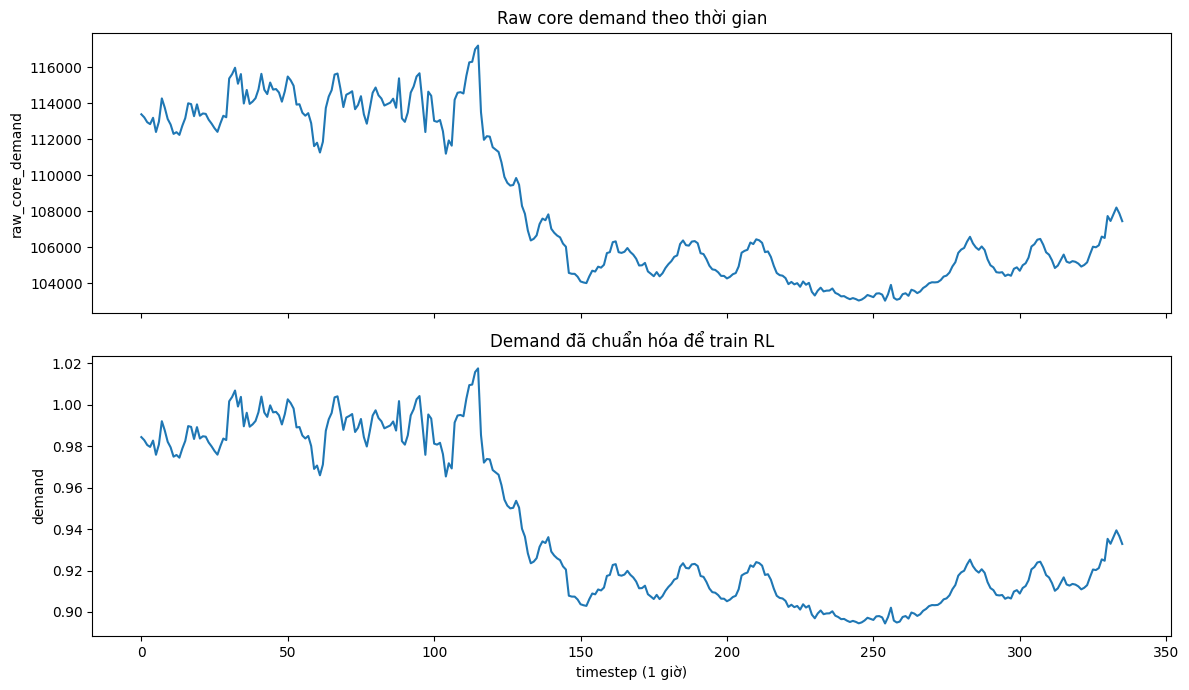

In [18]:

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(workload_df["timestep"], workload_df["raw_core_demand"])
axes[0].set_title("Raw core demand theo thời gian")
axes[0].set_ylabel("raw_core_demand")

axes[1].plot(workload_df["timestep"], workload_df["demand"])
axes[1].set_title("Demand đã chuẩn hóa để train RL")
axes[1].set_xlabel("timestep (1 giờ)")
axes[1].set_ylabel("demand")

plt.tight_layout()
plt.show()



## Bước 11 - Xem thêm số VM active theo thời gian
Cột này chưa dùng trực tiếp để train, nhưng rất hữu ích để:
- hiểu dữ liệu
- làm web demo
- vẽ thêm biểu đồ trong báo cáo


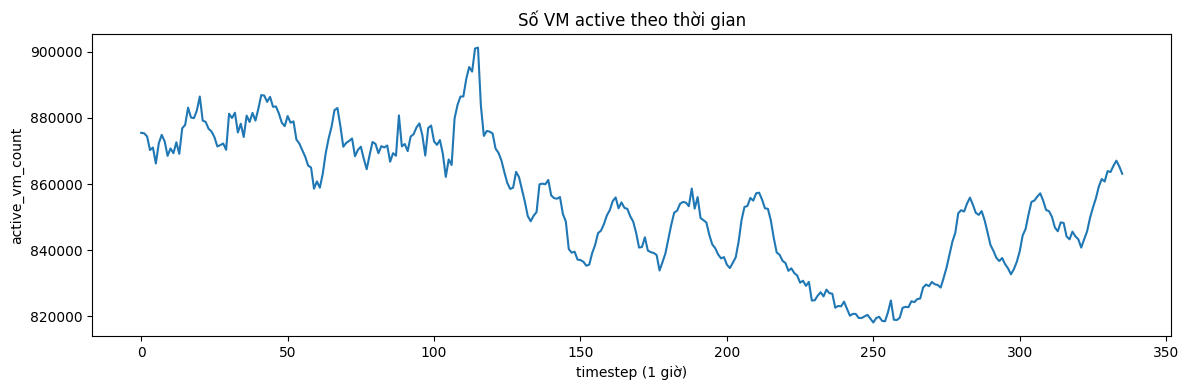

In [19]:

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["active_vm_count"])
plt.title("Số VM active theo thời gian")
plt.xlabel("timestep (1 giờ)")
plt.ylabel("active_vm_count")
plt.tight_layout()
plt.show()



## Bước 12 - Kiểm tra file CSV đã được lưu chưa
Nếu cell này trả về `True` là bạn đã xong notebook 1.


In [20]:

OUTPUT_CSV.exists()


True


## Kết luận notebook 1

Sau notebook này, bạn đã có:
- file workload thật lấy từ Azure Packing Trace
- file đó ở dạng CSV
- và có thể dùng ngay cho notebook train PPO

### File đầu ra quan trọng nhất:
`data/workload_real.csv`

Giờ bạn chuyển sang notebook 2.
